# Langkah 1: Memuat Dataset

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_excel('16_prediksi_risiko_kredit.xlsx')
df

,Customer ID,Age,Annual Income (IDR),Loan Amount (IDR),Repayment History,Credit Risk
0,1,48,44497054,24661007,1,0
1,2,48,41319247,18863529,1,0
2,3,30,91585037,17569021,1,1
3,4,51,111022004,75605469,0,0
4,5,21,76048559,60280248,0,1
...,...,...,...,...,...,...
295,296,27,72778076,46727753,1,1
296,297,44,40758430,80008148,0,0
297,298,23,50778286,6003171,0,1
298,299,52,87697272,54701515,0,0


# Langkah 2: Visualisasi Data

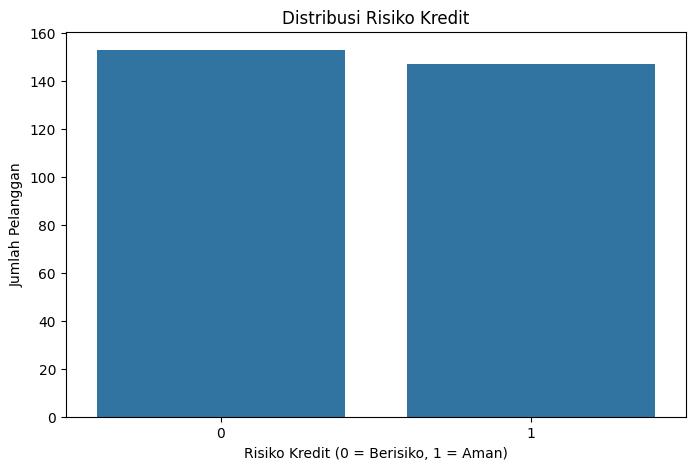

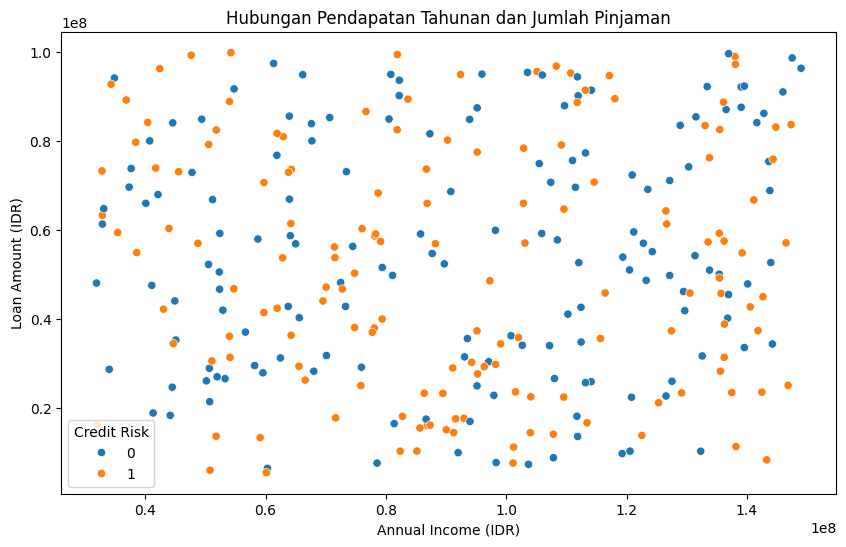

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi distribusi risiko kredit
plt.figure(figsize=(8, 5))
sns.countplot(x='Credit Risk', data=df)
plt.title('Distribusi Risiko Kredit')
plt.xlabel('Risiko Kredit (0 = Berisiko, 1 = Aman)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

# Visualisasi hubungan antara pendapatan tahunan dan jumlah pinjaman
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (IDR)', y='Loan Amount (IDR)', hue='Credit Risk', data=df)
plt.title('Hubungan Pendapatan Tahunan dan Jumlah Pinjaman')
plt.show()


# Langkah 3: Preprocessing Data

In [ ]:

# Memilih fitur dan target
X = df[['Age', 'Annual Income (IDR)', 'Loan Amount (IDR)', 'Repayment History']]
y = df['Credit Risk']


# Langkah 4: Normalisasi Data

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Langkah 5: Membagi Data Train dan Test

In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


# Langkah 6: Melatih Model

In [ ]:

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# Langkah 7: Evaluasi Model

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)
print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Akurasi Model: 0.6666666666666666
Confusion Matrix:
[[30 16]
 [14 30]]
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.65      0.67        46
           1       0.65      0.68      0.67        44

    accuracy                           0.67        90
   macro avg       0.67      0.67      0.67        90
weighted avg       0.67      0.67      0.67        90



# Langkah 8: Prediksi

In [ ]:

# Contoh prediksi untuk pelanggan baru
sample_data = np.array([[35, 50000000, 10000000, 1]])
sample_data_scaled = scaler.transform(sample_data)
prediction = model.predict(sample_data_scaled)
print("Prediksi Risiko Kredit (0 = Berisiko, 1 = Aman):", prediction[0])


Prediksi Risiko Kredit (0 = Berisiko, 1 = Aman): 0


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
